# CNN 2D: Waymo Maneuver Classification

This notebook continues from CNN_2D_resplit.ipynb. It:

1. Creates X_train.csv, X_val.csv, and X_test.csv from the target-frame paths.
2. Retains RGB color and resizes every image to a consistent shape.
3. Builds a tunable TensorFlow 2D CNN.
4. Trains an initial CNN on the training split.
5. Selects hyperparameters using only the validation split.
6. Compares the selected CNN with chance and majority-class baselines.
7. Reports final metrics on the untouched test split.

The test split is not used for model or hyperparameter selection.

## Why retain color?

This notebook keeps three RGB channels. Color may help the CNN recognize traffic lights, lane markings, vehicle lights, road conditions, and other visual cues. Grayscale would reduce the feature size and storage by roughly two-thirds, but it would also discard that information.

The images are resized to 96 by 256 pixels to retain a wide driving view while controlling memory and training time. The flattened CSV files can still be large because CSV is a text format.

# Step 1: Import packages and set reproducible behavior

In [1]:
import gc
import os
import random
import time
from pathlib import Path

# Reduce TensorFlow startup messages while retaining warnings and errors.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

SEED = 42

# Set Python, NumPy, and TensorFlow seeds.
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Request deterministic TensorFlow operations when supported.
try:
    tf.config.experimental.enable_op_determinism()
    print('TensorFlow deterministic operations enabled.')
except (AttributeError, RuntimeError) as error:
    print(f'Deterministic operations could not be enabled: {error}')

# Allow TensorFlow to increase GPU memory use as needed.
gpu_devices = tf.config.list_physical_devices('GPU')
for gpu_device in gpu_devices:
    try:
        tf.config.experimental.set_memory_growth(gpu_device, True)
    except RuntimeError:
        pass

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')
print(f'GPU devices found: {len(gpu_devices)}')
for gpu_device in gpu_devices:
    print(f'  {gpu_device}')

TensorFlow deterministic operations enabled.
TensorFlow version: 2.21.0
NumPy version: 2.3.5
Pandas version: 2.3.3
GPU devices found: 0


# Step 2: Define paths and image settings

In [2]:
# Use the project root whether the notebook starts from the project root
# or from inside the notebooks directory.
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir

CNN_DATA_DIR = (
    PROJECT_ROOT
    / 'data'
    / 'processed'
    / 'waymo_e2e'
    / 'CNN_2D'
)
CNN_DATA_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_NAMES = ['train', 'val', 'test']

DF_PATHS = {
    split_name: CNN_DATA_DIR / f'df_{split_name}.csv'
    for split_name in SPLIT_NAMES
}
Y_PATHS = {
    split_name: CNN_DATA_DIR / f'y_{split_name}.csv'
    for split_name in SPLIT_NAMES
}
X_PATHS = {
    split_name: CNN_DATA_DIR / f'X_{split_name}.csv'
    for split_name in SPLIT_NAMES
}

# RGB is retained by default.
IMAGE_HEIGHT = 96
IMAGE_WIDTH = 256
USE_GRAYSCALE = False
IMAGE_CHANNELS = 1 if USE_GRAYSCALE else 3
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS)
N_FLAT_FEATURES = int(np.prod(INPUT_SHAPE))

# Change to True when intentionally rebuilding the flattened CSV files.
OVERWRITE_X_CSVS = False
CSV_WRITE_BATCH_SIZE = 16

required_input_paths = list(DF_PATHS.values()) + list(Y_PATHS.values())
for required_path in required_input_paths:
    if not required_path.exists():
        raise FileNotFoundError(f'Required input file not found: {required_path}')

print(f'Project root: {PROJECT_ROOT}')
print(f'CNN data directory: {CNN_DATA_DIR}')
print(f'Image input shape: {INPUT_SHAPE}')
print(f'Flattened features per image: {N_FLAT_FEATURES:,}')
print(f'Color mode: {"grayscale" if USE_GRAYSCALE else "RGB"}')

Project root: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final
CNN data directory: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_2D
Image input shape: (96, 256, 3)
Flattened features per image: 73,728
Color mode: RGB


# Step 3: Load and verify the split dataframes and labels

The row order in each df file defines the row order in the matching X and y files. The checks below prevent image and label misalignment.

In [3]:
split_dfs = {}
split_label_dfs = {}
split_summary_rows = []

for split_name in SPLIT_NAMES:
    split_df = pd.read_csv(DF_PATHS[split_name])
    label_df = pd.read_csv(Y_PATHS[split_name])

    required_columns = {'target_frame_path', 'class_label'}
    if not required_columns.issubset(split_df.columns):
        raise ValueError(
            f'{DF_PATHS[split_name].name} must contain '
            f'{sorted(required_columns)}'
        )

    if list(label_df.columns) != ['class_label']:
        raise ValueError(
            f'{Y_PATHS[split_name].name} must contain only class_label'
        )

    if len(split_df) != len(label_df):
        raise ValueError(
            f'Row mismatch for {split_name}: '
            f'{len(split_df)} dataframe rows and {len(label_df)} labels'
        )

    if not split_df['class_label'].reset_index(drop=True).equals(
        label_df['class_label'].reset_index(drop=True)
    ):
        raise ValueError(f'Label order mismatch in the {split_name} split')

    split_dfs[split_name] = split_df
    split_label_dfs[split_name] = label_df

    class_counts = split_df['class_label'].value_counts()
    split_summary_rows.append({
        'split': split_name,
        'images': len(split_df),
        'straight': int(class_counts.get('straight', 0)),
        'right-turn': int(class_counts.get('right-turn', 0)),
        'left-turn': int(class_counts.get('left-turn', 0)),
    })

split_summary_df = pd.DataFrame(split_summary_rows)
display(split_summary_df)

for split_name in SPLIT_NAMES:
    print(f'\n{split_name.upper()} class distribution:')
    counts = split_dfs[split_name]['class_label'].value_counts()
    percentages = counts / len(split_dfs[split_name]) * 100

    for class_name in ['straight', 'right-turn', 'left-turn']:
        print(
            f'  {class_name}: {counts.get(class_name, 0):,} '
            f'({percentages.get(class_name, 0):.2f}%)'
        )

,split,images,straight,right-turn,left-turn
0,train,1376,634,412,330
1,val,295,136,89,70
2,test,295,136,88,71



TRAIN class distribution:
  straight: 634 (46.08%)
  right-turn: 412 (29.94%)
  left-turn: 330 (23.98%)

VAL class distribution:
  straight: 136 (46.10%)
  right-turn: 89 (30.17%)
  left-turn: 70 (23.73%)

TEST class distribution:
  straight: 136 (46.10%)
  right-turn: 88 (29.83%)
  left-turn: 71 (24.07%)


# Step 4: Create flattened RGB image CSV files

Each row in an X CSV contains one resized image flattened in row-major height-width-channel order. The files include pixel_0 through pixel_N column headers. Pixel values remain uint8 values from 0 through 255; normalization is performed inside the CNN.

No horizontal flip augmentation is used because flipping would change left turns into right turns and would invalidate the labels.

In [4]:
def resolve_frame_path(path_value):
    # Support either project-relative paths or absolute paths.
    frame_path = Path(path_value)
    if frame_path.is_absolute():
        return frame_path
    return PROJECT_ROOT / frame_path


def load_image(fpath):
    # Load the first modality, which is the camera image in this dataset.
    with np.load(fpath, allow_pickle=True) as data:
        modality = data['_modality_data'].item()
        keys = list(modality.keys())
        img = np.asarray(modality[keys[0]])

    # Convert floating-point images to the standard uint8 range.
    if np.issubdtype(img.dtype, np.floating):
        if img.max() <= 1.0:
            img = img * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    return img


def prepare_image(fpath):
    # Load the original Waymo target frame.
    img = load_image(fpath)

    # Ensure the image has three color channels before optional grayscale.
    if img.ndim == 2:
        img = np.repeat(img[:, :, np.newaxis], 3, axis=2)

    if img.shape[-1] == 4:
        img = img[:, :, :3]

    if img.ndim != 3 or img.shape[-1] != 3:
        raise ValueError(f'Unexpected image shape at {fpath}: {img.shape}')

    image_tensor = tf.convert_to_tensor(img, dtype=tf.float32)

    if USE_GRAYSCALE:
        image_tensor = tf.image.rgb_to_grayscale(image_tensor)

    # Resize every image to the same dimensions for the CNN.
    image_tensor = tf.image.resize(
        image_tensor,
        size=(IMAGE_HEIGHT, IMAGE_WIDTH),
        method='bilinear',
        antialias=True,
    )

    return np.clip(
        np.rint(image_tensor.numpy()),
        0,
        255,
    ).astype(np.uint8)


def write_flattened_X_csv(
    split_df,
    output_path,
    overwrite=False,
    batch_size=16,
):
    # Reuse an existing file unless a rebuild was requested.
    if output_path.exists() and not overwrite:
        file_size_gb = output_path.stat().st_size / (1024 ** 3)
        print(
            f'{output_path.name} already exists '
            f'({file_size_gb:.3f} GB). Skipping rebuild.'
        )
        return

    start_time = time.perf_counter()
    header = ','.join(
        f'pixel_{feature_index}'
        for feature_index in range(N_FLAT_FEATURES)
    )
    flat_batch = []

    with open(output_path, 'w', encoding='utf-8', newline='') as output_file:
        output_file.write(header + '\n')

        for row_number, path_value in enumerate(
            split_df['target_frame_path'],
            start=1,
        ):
            frame_path = resolve_frame_path(path_value)

            if not frame_path.exists():
                raise FileNotFoundError(
                    f'Target frame not found: {frame_path}'
                )

            prepared_image = prepare_image(frame_path)
            flat_batch.append(prepared_image.reshape(-1))

            # Write a small batch at a time to limit memory use.
            if len(flat_batch) == batch_size:
                np.savetxt(
                    output_file,
                    np.stack(flat_batch),
                    delimiter=',',
                    fmt='%d',
                )
                flat_batch = []

            if row_number % 100 == 0 or row_number == len(split_df):
                print(
                    f'  {output_path.name}: '
                    f'{row_number:,}/{len(split_df):,} images processed'
                )

        # Write the final partial batch.
        if flat_batch:
            np.savetxt(
                output_file,
                np.stack(flat_batch),
                delimiter=',',
                fmt='%d',
            )

    elapsed_seconds = time.perf_counter() - start_time
    file_size_gb = output_path.stat().st_size / (1024 ** 3)
    print(
        f'Created {output_path.name}: {file_size_gb:.3f} GB '
        f'in {elapsed_seconds / 60:.2f} minutes'
    )

In [5]:
# Print lower-bound memory estimates before creating the text CSV files.
# Actual CSV sizes are larger because each value is written as text.
for split_name in SPLIT_NAMES:
    image_count = len(split_dfs[split_name])
    raw_size_gb = image_count * N_FLAT_FEATURES / (1024 ** 3)
    print(
        f'{split_name.upper()}: {image_count:,} images, '
        f'{raw_size_gb:.3f} GB as raw uint8 values before CSV text overhead'
    )

TRAIN: 1,376 images, 0.094 GB as raw uint8 values before CSV text overhead
VAL: 295 images, 0.020 GB as raw uint8 values before CSV text overhead
TEST: 295 images, 0.020 GB as raw uint8 values before CSV text overhead


In [6]:
# Create one flattened feature CSV for each existing split.
for split_name in SPLIT_NAMES:
    print(f'\nCreating {X_PATHS[split_name].name}')
    write_flattened_X_csv(
        split_df=split_dfs[split_name],
        output_path=X_PATHS[split_name],
        overwrite=OVERWRITE_X_CSVS,
        batch_size=CSV_WRITE_BATCH_SIZE,
    )


Creating X_train.csv
X_train.csv already exists (0.328 GB). Skipping rebuild.

Creating X_val.csv
X_val.csv already exists (0.071 GB). Skipping rebuild.

Creating X_test.csv
X_test.csv already exists (0.070 GB). Skipping rebuild.


# Step 5: Load the flattened CSV files and reshape them for the CNN

The CSV files store one flat vector per image. A Conv2D layer requires image tensors, so each row is reshaped back to height by width by channels.

In [7]:
CLASS_NAMES = ['straight', 'right-turn', 'left-turn']
CLASS_TO_ID = {
    class_name: class_id
    for class_id, class_name in enumerate(CLASS_NAMES)
}
ID_TO_CLASS = {
    class_id: class_name
    for class_name, class_id in CLASS_TO_ID.items()
}
NUM_CLASSES = len(CLASS_NAMES)


def load_X_csv(csv_path, expected_rows):
    start_time = time.perf_counter()

    # Skip the pixel-name header and retain compact uint8 values.
    X_flat = np.loadtxt(
        csv_path,
        delimiter=',',
        skiprows=1,
        dtype=np.uint8,
    )
    X_flat = np.atleast_2d(X_flat)

    expected_shape = (expected_rows, N_FLAT_FEATURES)
    if X_flat.shape != expected_shape:
        raise ValueError(
            f'{csv_path.name} has shape {X_flat.shape}; '
            f'expected {expected_shape}. If image settings changed, set '
            f'OVERWRITE_X_CSVS=True and rebuild the X CSV files.'
        )

    X_images = X_flat.reshape((-1,) + INPUT_SHAPE)
    elapsed_seconds = time.perf_counter() - start_time
    memory_gb = X_images.nbytes / (1024 ** 3)

    print(
        f'Loaded {csv_path.name}: shape={X_images.shape}, '
        f'dtype={X_images.dtype}, memory={memory_gb:.3f} GB, '
        f'time={elapsed_seconds:.1f} seconds'
    )

    return X_images


def encode_labels(label_df):
    encoded = label_df['class_label'].map(CLASS_TO_ID)

    if encoded.isna().any():
        unknown_labels = label_df.loc[
            encoded.isna(),
            'class_label',
        ].unique()
        raise ValueError(f'Unknown class labels: {unknown_labels}')

    return encoded.to_numpy(dtype=np.int32)


X_train = load_X_csv(X_PATHS['train'], len(split_dfs['train']))
X_val = load_X_csv(X_PATHS['val'], len(split_dfs['val']))
X_test = load_X_csv(X_PATHS['test'], len(split_dfs['test']))

y_train = encode_labels(split_label_dfs['train'])
y_val = encode_labels(split_label_dfs['val'])
y_test = encode_labels(split_label_dfs['test'])

print(f'\nX_train shape: {X_train.shape}; y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}; y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}; y_test shape: {y_test.shape}')

Loaded X_train.csv: shape=(1376, 96, 256, 3), dtype=uint8, memory=0.094 GB, time=16.7 seconds
Loaded X_val.csv: shape=(295, 96, 256, 3), dtype=uint8, memory=0.020 GB, time=3.5 seconds
Loaded X_test.csv: shape=(295, 96, 256, 3), dtype=uint8, memory=0.020 GB, time=3.5 seconds

X_train shape: (1376, 96, 256, 3); y_train shape: (1376,)
X_val shape: (295, 96, 256, 3); y_val shape: (295,)
X_test shape: (295, 96, 256, 3); y_test shape: (295,)


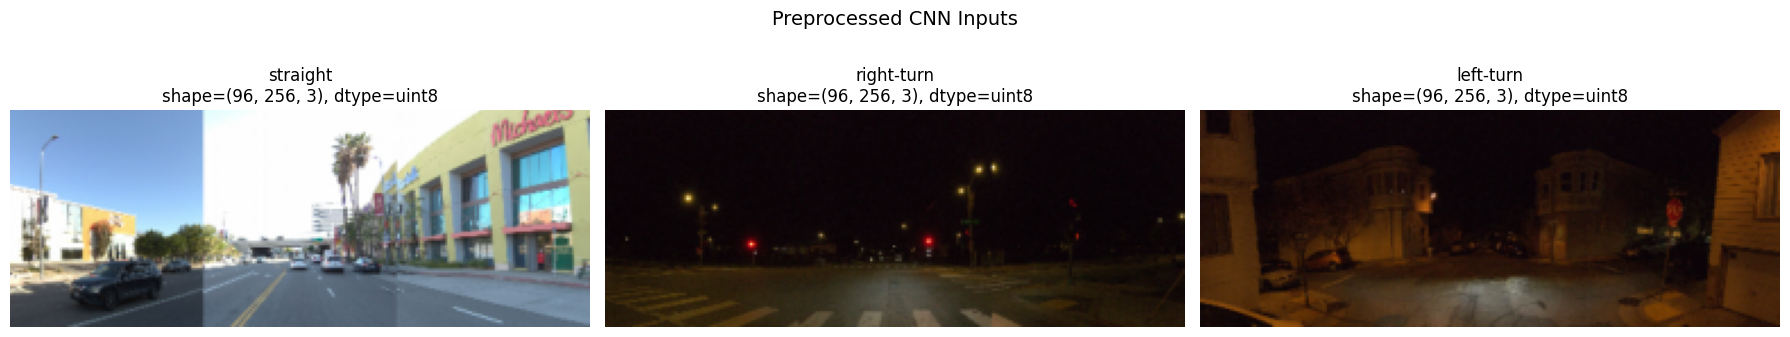

In [8]:
# Display one resized RGB example from each class.
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))

for class_id, ax in enumerate(axes):
    example_index = np.flatnonzero(y_train == class_id)[0]
    example_image = X_train[example_index]

    if IMAGE_CHANNELS == 1:
        ax.imshow(example_image.squeeze(), cmap='gray')
    else:
        ax.imshow(example_image)

    ax.set_title(
        f'{ID_TO_CLASS[class_id]}\n'
        f'shape={example_image.shape}, dtype={example_image.dtype}'
    )
    ax.axis('off')

plt.suptitle('Preprocessed CNN Inputs', fontsize=14)
plt.tight_layout()
plt.show()

# Step 6: Define evaluation and plotting functions

For multiclass classification, sensitivity is the recall calculated for each class in a one-versus-rest comparison. Therefore, macro sensitivity and macro recall are numerically identical. Both names are included in the metric tables for clarity.

In [9]:
def calculate_metrics(y_true, y_pred, model_name):
    recall_macro = recall_score(
        y_true,
        y_pred,
        average='macro',
        zero_division=0,
    )

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        ),
        'recall_macro': recall_macro,
        'sensitivity_macro': recall_macro,
        'f1_macro': f1_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        ),
        'precision_weighted': precision_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0,
        ),
        'recall_weighted': recall_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0,
        ),
        'f1_weighted': f1_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0,
        ),
    }


def classification_report_df(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T


def plot_confusion_matrices(y_true, y_pred, model_name):
    count_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
    )
    normalized_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        normalize='true',
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=count_matrix,
        display_labels=CLASS_NAMES,
    ).plot(
        ax=axes[0],
        cmap='Blues',
        colorbar=False,
        values_format='d',
    )
    axes[0].set_title(f'{model_name}: Count Confusion Matrix')
    axes[0].tick_params(axis='x', rotation=25)

    ConfusionMatrixDisplay(
        confusion_matrix=normalized_matrix,
        display_labels=CLASS_NAMES,
    ).plot(
        ax=axes[1],
        cmap='Blues',
        colorbar=False,
        values_format='.2f',
    )
    axes[1].set_title(f'{model_name}: Row-Normalized Matrix')
    axes[1].tick_params(axis='x', rotation=25)

    plt.tight_layout()
    plt.show()


def plot_training_history(history, title):
    history_values = (
        history.history
        if hasattr(history, 'history')
        else history
    )
    epoch_values = np.arange(1, len(history_values['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(
        epoch_values,
        history_values['loss'],
        marker='o',
        label='Training loss',
    )
    axes[0].plot(
        epoch_values,
        history_values['val_loss'],
        marker='o',
        label='Validation loss',
    )
    axes[0].set_title(f'{title}: Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        epoch_values,
        history_values['accuracy'],
        marker='o',
        label='Training accuracy',
    )
    axes[1].plot(
        epoch_values,
        history_values['val_accuracy'],
        marker='o',
        label='Validation accuracy',
    )
    axes[1].set_title(f'{title}: Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Step 7: Put the TensorFlow CNN into a tunable function

The main tunable hyperparameters are:

- convolution filter counts and network depth;
- convolution kernel size;
- dense-layer width;
- dropout;
- L2 regularization;
- Adam learning rate;
- batch size.

The CNN normalizes uint8 pixels internally. Batch normalization and dropout are used to stabilize training and limit overfitting.

In [10]:
MODEL_CONFIG_KEYS = [
    'conv_filters',
    'kernel_size',
    'dense_units',
    'dropout_rate',
    'learning_rate',
    'l2_strength',
]


def build_cnn_model(
    input_shape,
    conv_filters=(16, 32),
    kernel_size=3,
    dense_units=64,
    dropout_rate=0.25,
    learning_rate=0.001,
    l2_strength=0.0001,
):
    inputs = tf.keras.Input(
        shape=input_shape,
        name='rgb_image',
    )

    # Normalize raw uint8 pixels to the 0-to-1 range.
    x = tf.keras.layers.Rescaling(
        scale=1.0 / 255.0,
        name='pixel_rescaling',
    )(inputs)

    # Build one convolution and pooling block per filter value.
    for block_number, filter_count in enumerate(
        conv_filters,
        start=1,
    ):
        x = tf.keras.layers.Conv2D(
            filters=filter_count,
            kernel_size=kernel_size,
            padding='same',
            # use_bias=False,
            use_bias=True,
            kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
            name=f'conv_{block_number}',
        )(x)
        # x = tf.keras.layers.BatchNormalization(
        #     name=f'batch_norm_{block_number}',
        # )(x)
        x = tf.keras.layers.ReLU(
            name=f'relu_{block_number}',
        )(x)
        x = tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            name=f'max_pool_{block_number}',
        )(x)

        # Use lighter dropout inside convolution blocks.
        x = tf.keras.layers.Dropout(
            rate=dropout_rate / 2,
            name=f'conv_dropout_{block_number}',
        )(x)

    # Global average pooling keeps the parameter count manageable.
    # x = tf.keras.layers.GlobalAveragePooling2D(
    #     name='global_average_pool',
    # )(x)

    # Reduce the feature map while retaining coarse spatial positions.
    x = tf.keras.layers.AveragePooling2D(
        pool_size=(3, 4),
        name='coarse_spatial_pool',
    )(x)
    
    # Flatten the remaining spatial grid for classification.
    x = tf.keras.layers.Flatten(
        name='flatten',
    )(x)
    
    x = tf.keras.layers.Dense(
        units=dense_units,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name='dense_hidden',
    )(x)
    x = tf.keras.layers.Dropout(
        rate=dropout_rate,
        name='dense_dropout',
    )(x)

    outputs = tf.keras.layers.Dense(
        units=NUM_CLASSES,
        activation='softmax',
        name='class_probabilities',
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name='waymo_2d_cnn',
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    return model


def build_model_from_config(config):
    model_kwargs = {
        key: config[key]
        for key in MODEL_CONFIG_KEYS
    }
    return build_cnn_model(
        input_shape=INPUT_SHAPE,
        **model_kwargs,
    )

In [11]:
def count_model_parameters(model):
    trainable_parameters = int(sum(
        np.prod(variable.shape)
        for variable in model.trainable_weights
    ))
    non_trainable_parameters = int(sum(
        np.prod(variable.shape)
        for variable in model.non_trainable_weights
    ))

    return {
        'total_parameters': int(model.count_params()),
        'trainable_parameters': trainable_parameters,
        'non_trainable_parameters': non_trainable_parameters,
    }


# def selection_score(result_record):
#     # Prefer validation accuracy, then macro F1, then lower validation loss.
#     return (
#         result_record['validation_accuracy'],
#         result_record['validation_f1_macro'],
#         -result_record['validation_loss'],
#     )


def selection_score(result_record):
    # Prioritize balanced performance across all three maneuver classes.
    return (
        result_record['validation_f1_macro'],
        result_record['validation_accuracy'],
        -result_record['validation_loss'],
    )


def train_and_validate_model(
    config,
    trial_name,
    X_train,
    y_train,
    X_val,
    y_val,
    max_epochs=20,
    patience=4,
):
    print('=' * 100)
    print(f'TRIAL: {trial_name}')
    print('Hyperparameters:')
    for parameter_name, parameter_value in config.items():
        print(f'  {parameter_name}: {parameter_value}')

    # Reset state so trials begin from a reproducible initialization.
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = build_model_from_config(config)
    print('\nModel summary:')
    model.summary()

    parameter_counts = count_model_parameters(model)
    print('\nParameter counts:')
    for parameter_name, parameter_value in parameter_counts.items():
        print(f'  {parameter_name}: {parameter_value:,}')

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            mode='max',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=max(1, patience // 2),
            min_lr=1e-6,
            verbose=1,
        ),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

    start_time = time.perf_counter()

    # verbose=1 displays per-epoch and per-batch training information.
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=config['batch_size'],
        shuffle=True,
        callbacks=callbacks,
        verbose=1,
    )

    elapsed_seconds = time.perf_counter() - start_time

    validation_results = model.evaluate(
        X_val,
        y_val,
        batch_size=config['batch_size'],
        verbose=1,
        return_dict=True,
    )
    validation_probabilities = model.predict(
        X_val,
        batch_size=config['batch_size'],
        verbose=1,
    )
    validation_predictions = np.argmax(
        validation_probabilities,
        axis=1,
    )

    validation_metrics = calculate_metrics(
        y_val,
        validation_predictions,
        trial_name,
    )
    best_epoch = int(
        np.argmax(history.history['val_accuracy']) + 1
    )

    result_record = {
        'trial': trial_name,
        'conv_filters': str(config['conv_filters']),
        'kernel_size': config['kernel_size'],
        'dense_units': config['dense_units'],
        'dropout_rate': config['dropout_rate'],
        'learning_rate': config['learning_rate'],
        'l2_strength': config['l2_strength'],
        'batch_size': config['batch_size'],
        'epochs_run': len(history.history['loss']),
        'best_epoch': best_epoch,
        'total_parameters': parameter_counts['total_parameters'],
        'validation_loss': validation_results['loss'],
        'validation_accuracy': validation_results['accuracy'],
        'validation_precision_macro': (
            validation_metrics['precision_macro']
        ),
        'validation_recall_macro': (
            validation_metrics['recall_macro']
        ),
        'validation_sensitivity_macro': (
            validation_metrics['sensitivity_macro']
        ),
        'validation_f1_macro': validation_metrics['f1_macro'],
        'training_seconds': elapsed_seconds,
    }

    print('\nRestored-model validation results:')
    for metric_name, metric_value in result_record.items():
        print(f'  {metric_name}: {metric_value}')

    plot_training_history(history, trial_name)

    return model, history, result_record

# Step 8: Train the initial CNN

This establishes a starting CNN before tuning. It is trained only on X_train and monitored on X_val.

TRIAL: Initial CNN
Hyperparameters:
  conv_filters: (16, 32)
  kernel_size: 3
  dense_units: 64
  dropout_rate: 0.25
  learning_rate: 0.001
  l2_strength: 0.0001
  batch_size: 32


Model summary:


Model: "waymo_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rgb_image (InputLayer)               │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 96, 256, 16)         │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 96, 256, 16)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_1 (MaxPooling2D)            │ (None, 48, 128, 16)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 48, 128, 16)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 48, 128, 32)         │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_2 (MaxPooling2D)            │ (None, 24, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 24, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatial_pool                  │ (None, 8, 16, 32)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         262,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 267,491 (1.02 MB)

 Trainable params: 267,491 (1.02 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 267,491
  trainable_parameters: 267,491
  non_trainable_parameters: 0
Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.4615 - loss: 1.0777 - val_accuracy: 0.4610 - val_loss: 1.0707 - learning_rate: 0.0010
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.4615 - loss: 1.0577 - val_accuracy: 0.4610 - val_loss: 1.0413 - learning_rate: 0.0010
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.4847 - loss: 1.0223 - val_accuracy: 0.5322 - val_loss: 1.0235 - learning_rate: 0.0010
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.5334 - loss: 0.9828 - val_accuracy: 0.5559 - val_loss: 1.0131 - learning_rate: 0.0010
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.5523 - loss: 0.9606 - val_accuracy: 0.5797 - val_loss: 0.9846 - learning_rate: 0.0010
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.5589 - loss: 0.9438 - val_accuracy: 0.5593 - val_loss: 0.9823 - l

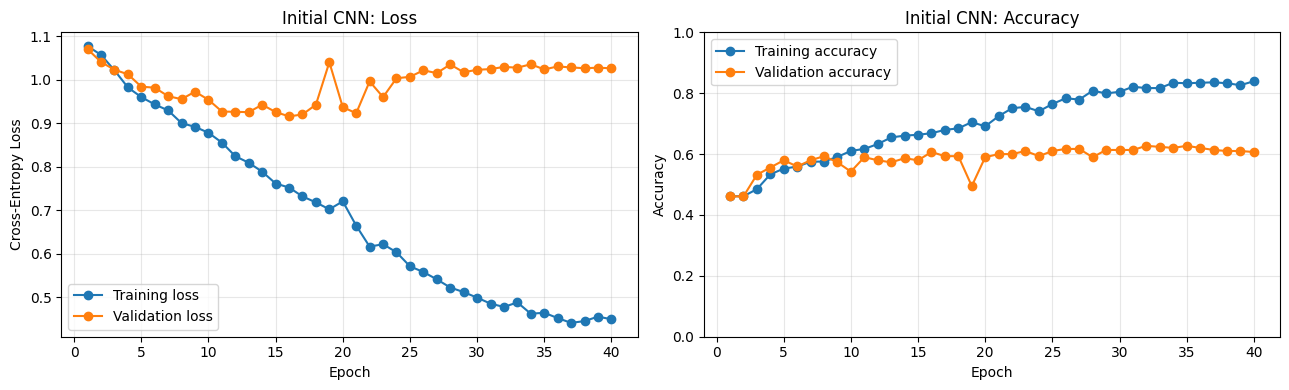

7514

In [12]:
INITIAL_CONFIG = {
    'conv_filters': (16, 32),
    'kernel_size': 3,
    'dense_units': 64,
    'dropout_rate': 0.25,
    'learning_rate': 0.001,
    'l2_strength': 0.0001,
    'batch_size': 32,
}

INITIAL_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 8

initial_model, initial_history, initial_result = train_and_validate_model(
    config=INITIAL_CONFIG,
    trial_name='Initial CNN',
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    max_epochs=INITIAL_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
)

tuning_records = [initial_result]
best_score = selection_score(initial_result)
best_config = INITIAL_CONFIG.copy()
best_trial_name = 'Initial CNN'
best_weights = [
    weight.copy()
    for weight in initial_model.get_weights()
]
best_history = {
    key: values.copy()
    for key, values in initial_history.history.items()
}

del initial_model
gc.collect()

# Step 9: Tune hyperparameters on the validation split

The configurations below form a compact, purposeful search rather than a very large Cartesian grid. They test model capacity, learning rate, regularization, depth, kernel size, and batch size.

Every candidate is trained on the training split. Selection uses validation accuracy, with validation macro F1 and validation loss as tie-breakers. The test split remains untouched.

In [13]:
TUNING_EPOCHS = 40

TUNING_CONFIGS = [
    {
        'name': 'Medium capacity',
        'conv_filters': (32, 64),
        'kernel_size': 3,
        'dense_units': 64,
        'dropout_rate': 0.30,
        'learning_rate': 0.001,
        'l2_strength': 0.0001,
        'batch_size': 32,
    },
    {
        'name': 'Medium capacity lower learning rate',
        'conv_filters': (32, 64),
        'kernel_size': 3,
        'dense_units': 64,
        'dropout_rate': 0.30,
        'learning_rate': 0.0003,
        'l2_strength': 0.0001,
        'batch_size': 32,
    },
    {
        'name': 'Stronger regularization',
        'conv_filters': (32, 64),
        'kernel_size': 3,
        'dense_units': 64,
        'dropout_rate': 0.45,
        'learning_rate': 0.0003,
        'l2_strength': 0.0005,
        'batch_size': 32,
    },
    {
        'name': 'Deeper CNN',
        'conv_filters': (32, 64, 128),
        'kernel_size': 3,
        'dense_units': 128,
        'dropout_rate': 0.40,
        'learning_rate': 0.0003,
        'l2_strength': 0.0001,
        'batch_size': 32,
    },
    {
        'name': 'Wider kernel',
        'conv_filters': (32, 64),
        'kernel_size': 5,
        'dense_units': 64,
        'dropout_rate': 0.35,
        'learning_rate': 0.0003,
        'l2_strength': 0.0001,
        'batch_size': 32,
    },
]

print(f'Additional tuning trials: {len(TUNING_CONFIGS)}')
for trial_number, trial_config in enumerate(TUNING_CONFIGS, start=1):
    print(f'\nTrial {trial_number}: {trial_config["name"]}')
    for parameter_name, parameter_value in trial_config.items():
        if parameter_name != 'name':
            print(f'  {parameter_name}: {parameter_value}')

Additional tuning trials: 5

Trial 1: Medium capacity
  conv_filters: (32, 64)
  kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.001
  l2_strength: 0.0001
  batch_size: 32

Trial 2: Medium capacity lower learning rate
  conv_filters: (32, 64)
  kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 32

Trial 3: Stronger regularization
  conv_filters: (32, 64)
  kernel_size: 3
  dense_units: 64
  dropout_rate: 0.45
  learning_rate: 0.0003
  l2_strength: 0.0005
  batch_size: 32

Trial 4: Deeper CNN
  conv_filters: (32, 64, 128)
  kernel_size: 3
  dense_units: 128
  dropout_rate: 0.4
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 32

Trial 5: Wider kernel
  conv_filters: (32, 64)
  kernel_size: 5
  dense_units: 64
  dropout_rate: 0.35
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 32


TRIAL: Medium capacity
Hyperparameters:
  conv_filters: (32, 64)
  kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.001
  l2_strength: 0.0001
  batch_size: 32

Model summary:


Model: "waymo_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rgb_image (InputLayer)               │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 96, 256, 32)         │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 96, 256, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_1 (MaxPooling2D)            │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 48, 128, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 48, 128, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_2 (MaxPooling2D)            │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatial_pool                  │ (None, 8, 16, 64)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 543,939 (2.07 MB)

 Trainable params: 543,939 (2.07 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 543,939
  trainable_parameters: 543,939
  non_trainable_parameters: 0
Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step - accuracy: 0.4622 - loss: 1.0834 - val_accuracy: 0.4610 - val_loss: 1.0707 - learning_rate: 0.0010
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.4637 - loss: 1.0672 - val_accuracy: 0.4610 - val_loss: 1.0450 - learning_rate: 0.0010
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 253ms/step - accuracy: 0.4920 - loss: 1.0224 - val_accuracy: 0.5288 - val_loss: 1.0444 - learning_rate: 0.0010
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 281ms/step - accuracy: 0.5262 - loss: 0.9939 - val_accuracy: 0.5220 - val_loss: 1.0238 - learning_rate: 0.0010
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 228ms/step - accuracy: 0.5436 - loss: 0.9602 - val_accuracy: 0.5356 - val_loss: 1.0157 - learning_rate: 0.0010
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.5516 - loss: 0.9436 - val_accuracy: 0.5220 - val_loss: 1.00

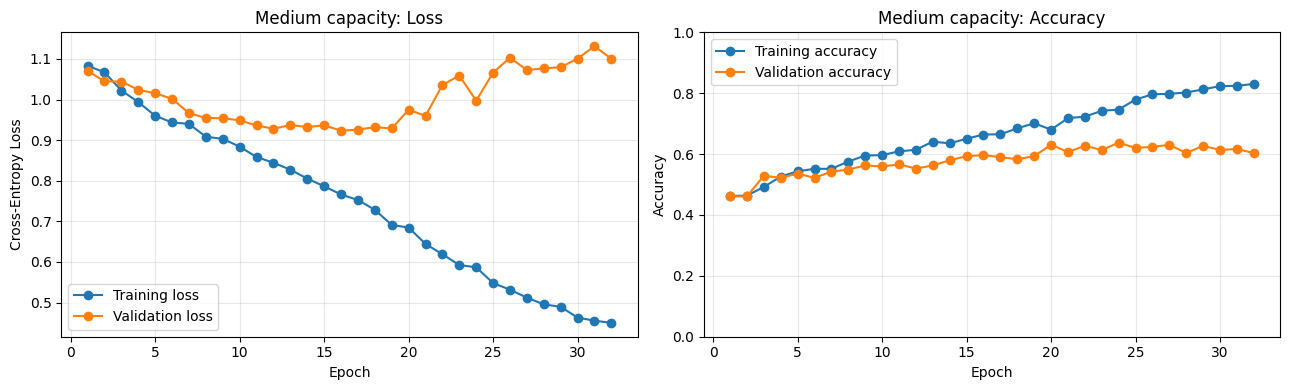


New best validation model: Medium capacity
Completed tuning trial 1/5
TRIAL: Medium capacity lower learning rate
Hyperparameters:
  conv_filters: (32, 64)
  kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 32

Model summary:


Model: "waymo_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rgb_image (InputLayer)               │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 96, 256, 32)         │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 96, 256, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_1 (MaxPooling2D)            │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 48, 128, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 48, 128, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_2 (MaxPooling2D)            │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatial_pool                  │ (None, 8, 16, 64)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 543,939 (2.07 MB)

 Trainable params: 543,939 (2.07 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 543,939
  trainable_parameters: 543,939
  non_trainable_parameters: 0
Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 232ms/step - accuracy: 0.4608 - loss: 1.0878 - val_accuracy: 0.4610 - val_loss: 1.0883 - learning_rate: 3.0000e-04
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 220ms/step - accuracy: 0.4608 - loss: 1.0711 - val_accuracy: 0.4610 - val_loss: 1.0707 - learning_rate: 3.0000e-04
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 0.4600 - loss: 1.0542 - val_accuracy: 0.4610 - val_loss: 1.0533 - learning_rate: 3.0000e-04
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 0.4775 - loss: 1.0302 - val_accuracy: 0.4644 - val_loss: 1.0219 - learning_rate: 3.0000e-04
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 232ms/step - accuracy: 0.5065 - loss: 1.0059 - val_accuracy: 0.5085 - val_loss: 1.0054 - learning_rate: 3.0000e-04
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step - accuracy: 0.5305 - loss: 0.9790 - val_accuracy: 0.53

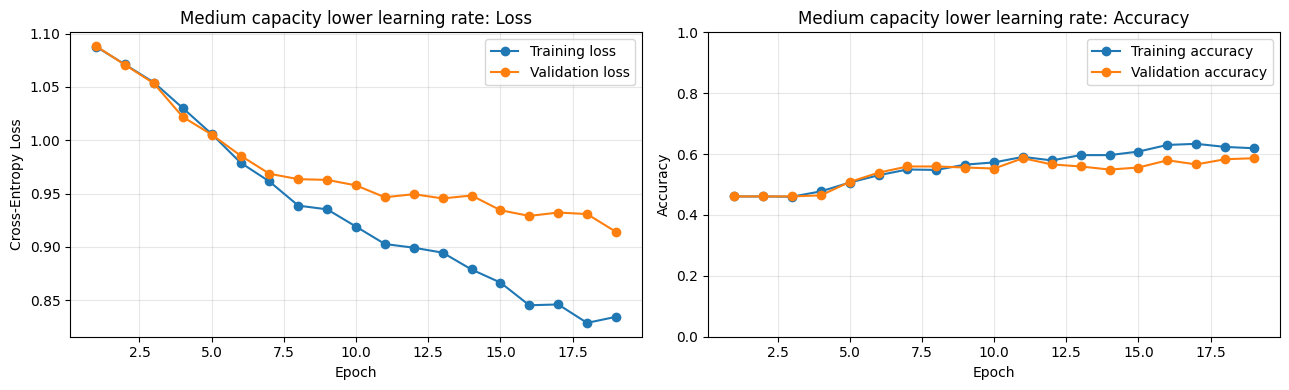

Completed tuning trial 2/5
TRIAL: Stronger regularization
Hyperparameters:
  conv_filters: (32, 64)
  kernel_size: 3
  dense_units: 64
  dropout_rate: 0.45
  learning_rate: 0.0003
  l2_strength: 0.0005
  batch_size: 32

Model summary:


Model: "waymo_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rgb_image (InputLayer)               │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 96, 256, 32)         │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 96, 256, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_1 (MaxPooling2D)            │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 48, 128, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 48, 128, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_2 (MaxPooling2D)            │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatial_pool                  │ (None, 8, 16, 64)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 543,939 (2.07 MB)

 Trainable params: 543,939 (2.07 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 543,939
  trainable_parameters: 543,939
  non_trainable_parameters: 0
Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.4549 - loss: 1.1485 - val_accuracy: 0.4610 - val_loss: 1.1396 - learning_rate: 3.0000e-04
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step - accuracy: 0.4600 - loss: 1.1190 - val_accuracy: 0.4610 - val_loss: 1.1222 - learning_rate: 3.0000e-04
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step - accuracy: 0.4586 - loss: 1.0975 - val_accuracy: 0.4610 - val_loss: 1.1024 - learning_rate: 3.0000e-04
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 222ms/step - accuracy: 0.4622 - loss: 1.0869 - val_accuracy: 0.4610 - val_loss: 1.0814 - learning_rate: 3.0000e-04
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step - accuracy: 0.4709 - loss: 1.0691 - val_accuracy: 0.4780 - val_loss: 1.0587 - learning_rate: 3.0000e-04
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 228ms/step - accuracy: 0.4869 - loss: 1.0415 - val_accuracy: 0.4

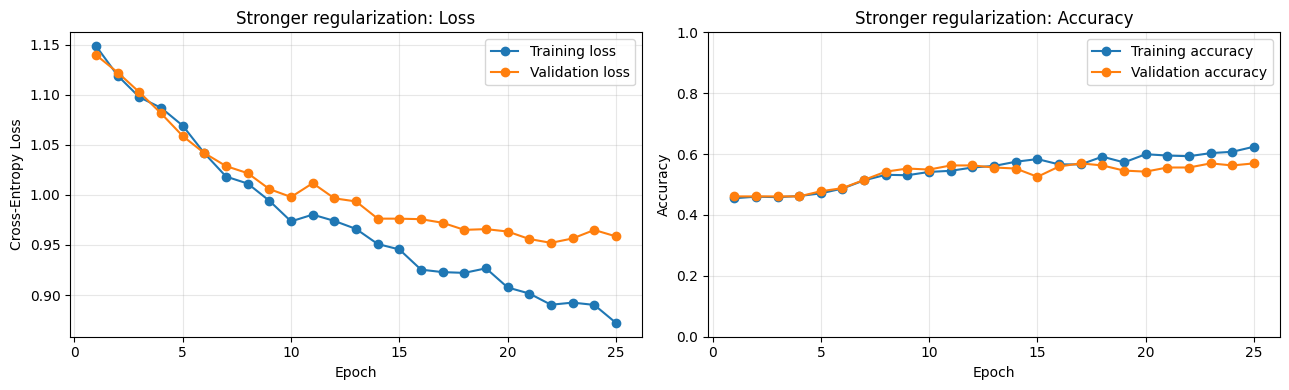

Completed tuning trial 3/5
TRIAL: Deeper CNN
Hyperparameters:
  conv_filters: (32, 64, 128)
  kernel_size: 3
  dense_units: 128
  dropout_rate: 0.4
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 32

Model summary:


Model: "waymo_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rgb_image (InputLayer)               │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 96, 256, 32)         │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 96, 256, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_1 (MaxPooling2D)            │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 48, 128, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 48, 128, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_2 (MaxPooling2D)            │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_3 (Conv2D)                      │ (None, 24, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_3 (ReLU)                        │ (None, 24, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_3 (MaxPooling2D)            │ (None, 12, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_3 (Dropout)             │ (None, 12, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatial_pool                  │ (None, 4, 8, 128)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 618,051 (2.36 MB)

 Trainable params: 618,051 (2.36 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 618,051
  trainable_parameters: 618,051
  non_trainable_parameters: 0
Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 318ms/step - accuracy: 0.4520 - loss: 1.1058 - val_accuracy: 0.4610 - val_loss: 1.1078 - learning_rate: 3.0000e-04
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 335ms/step - accuracy: 0.4608 - loss: 1.0902 - val_accuracy: 0.4610 - val_loss: 1.1015 - learning_rate: 3.0000e-04
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step - accuracy: 0.4608 - loss: 1.0854 - val_accuracy: 0.4610 - val_loss: 1.0947 - learning_rate: 3.0000e-04
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 311ms/step - accuracy: 0.4608 - loss: 1.0787 - val_accuracy: 0.4610 - val_loss: 1.0881 - learning_rate: 3.0000e-04
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 301ms/step - accuracy: 0.4622 - loss: 1.0711 - val_accuracy: 0.4610 - val_loss: 1.0782 - learning_rate: 3.0000e-04
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 304ms/step - accuracy: 0.4709 - loss: 1.0597 - val_accuracy: 0.4

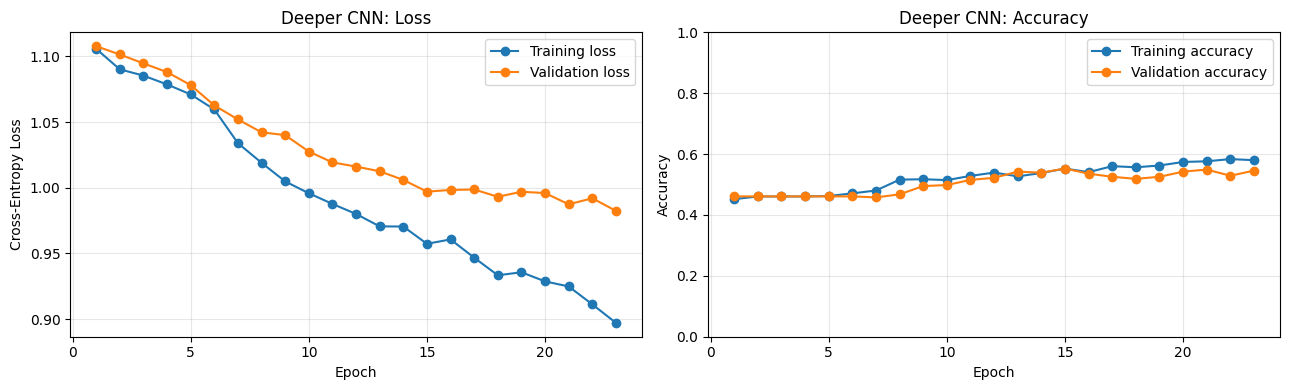

Completed tuning trial 4/5
TRIAL: Wider kernel
Hyperparameters:
  conv_filters: (32, 64)
  kernel_size: 5
  dense_units: 64
  dropout_rate: 0.35
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 32

Model summary:


Model: "waymo_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rgb_image (InputLayer)               │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 96, 256, 32)         │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 96, 256, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_1 (MaxPooling2D)            │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 48, 128, 64)         │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 48, 128, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_2 (MaxPooling2D)            │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatial_pool                  │ (None, 8, 16, 64)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 578,243 (2.21 MB)

 Trainable params: 578,243 (2.21 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 578,243
  trainable_parameters: 578,243
  non_trainable_parameters: 0
Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 343ms/step - accuracy: 0.4564 - loss: 1.0902 - val_accuracy: 0.4610 - val_loss: 1.0872 - learning_rate: 3.0000e-04
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 334ms/step - accuracy: 0.4608 - loss: 1.0781 - val_accuracy: 0.4610 - val_loss: 1.0794 - learning_rate: 3.0000e-04
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 343ms/step - accuracy: 0.4629 - loss: 1.0658 - val_accuracy: 0.4610 - val_loss: 1.0641 - learning_rate: 3.0000e-04
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 335ms/step - accuracy: 0.4688 - loss: 1.0459 - val_accuracy: 0.4712 - val_loss: 1.0515 - learning_rate: 3.0000e-04
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 333ms/step - accuracy: 0.4804 - loss: 1.0198 - val_accuracy: 0.5390 - val_loss: 1.0359 - learning_rate: 3.0000e-04
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 334ms/step - accuracy: 0.5000 - loss: 1.0052 - val_accuracy: 0.5

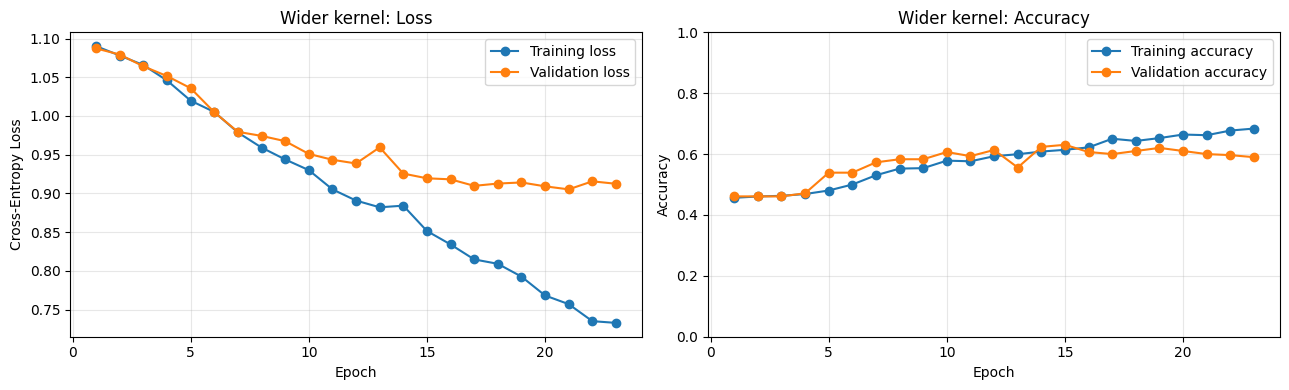

Completed tuning trial 5/5


In [14]:
for trial_number, trial_config in enumerate(
    TUNING_CONFIGS,
    start=1,
):
    trial_name = trial_config['name']
    model_config = {
        key: value
        for key, value in trial_config.items()
        if key != 'name'
    }

    trial_model, trial_history, trial_result = (
        train_and_validate_model(
            config=model_config,
            trial_name=trial_name,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            max_epochs=TUNING_EPOCHS,
            patience=EARLY_STOPPING_PATIENCE,
        )
    )

    tuning_records.append(trial_result)
    trial_score = selection_score(trial_result)

    if trial_score > best_score:
        best_score = trial_score
        best_config = model_config.copy()
        best_trial_name = trial_name
        best_weights = [
            weight.copy()
            for weight in trial_model.get_weights()
        ]
        best_history = {
            key: values.copy()
            for key, values in trial_history.history.items()
        }
        print(f'\nNew best validation model: {best_trial_name}')

    del trial_model
    del trial_history
    gc.collect()

    print(f'Completed tuning trial {trial_number}/{len(TUNING_CONFIGS)}')

In [15]:
tuning_results_df = pd.DataFrame(tuning_records)
tuning_results_df = tuning_results_df.sort_values(
    by=[
        'validation_f1_macro',
        'validation_accuracy',
        'validation_loss',
    ],
    ascending=[False, False, True],
).reset_index(drop=True)

# Round a display copy without requiring the optional Pandas Styler dependency.
tuning_results_display = tuning_results_df.copy()
four_decimal_columns = [
    'validation_loss',
    'validation_accuracy',
    'validation_precision_macro',
    'validation_recall_macro',
    'validation_sensitivity_macro',
    'validation_f1_macro',
]
tuning_results_display[four_decimal_columns] = (
    tuning_results_display[four_decimal_columns].round(4)
)
tuning_results_display['training_seconds'] = (
    tuning_results_display['training_seconds'].round(1)
)

print('Hyperparameter tuning results, ranked by validation performance:')
display(tuning_results_display)

print(f'\nSelected trial: {best_trial_name}')
print('Selected hyperparameters:')
for parameter_name, parameter_value in best_config.items():
    print(f'  {parameter_name}: {parameter_value}')

Hyperparameter tuning results, ranked by validation performance:


,trial,conv_filters,kernel_size,dense_units,dropout_rate,learning_rate,l2_strength,batch_size,epochs_run,best_epoch,total_parameters,validation_loss,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_sensitivity_macro,validation_f1_macro,training_seconds
0,Medium capacity,"(32, 64)",3,64,0.30,0.0010,0.0001,32,32,24,543939,0.9972,0.6373,0.6168,0.5899,0.5899,0.5965,321.4
1,Initial CNN,"(16, 32)",3,64,0.25,0.0010,0.0001,32,40,32,267491,1.0300,0.6271,0.6000,0.5780,0.5780,0.5826,187.0
2,Wider kernel,"(32, 64)",5,64,0.35,0.0003,0.0001,32,23,15,578243,0.9195,0.6305,0.6112,0.5589,0.5589,0.5557,335.5
3,Medium capacity lower learning rate,"(32, 64)",3,64,0.30,0.0003,0.0001,32,19,11,543939,0.9465,0.5864,0.5767,0.5323,0.5323,0.5392,187.8
4,Stronger regularization,"(32, 64)",3,64,0.45,0.0003,0.0005,32,25,17,543939,0.9722,0.5695,0.5436,0.5121,0.5121,0.5145,245.7
5,Deeper CNN,"(32, 64, 128)",3,128,0.40,0.0003,0.0001,32,23,15,618051,0.9971,0.5525,0.5263,0.4961,0.4961,0.4962,305.4



Selected trial: Medium capacity
Selected hyperparameters:
  conv_filters: (32, 64)
  kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.001
  l2_strength: 0.0001
  batch_size: 32


# Step 10: Rebuild the selected model and examine validation performance

The selected early-stopped weights are loaded into a fresh copy of the winning architecture. This avoids retraining and preserves the exact model selected from the validation experiments.

Selected model: Medium capacity


Model: "waymo_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rgb_image (InputLayer)               │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 96, 256, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 96, 256, 32)         │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 96, 256, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_1 (MaxPooling2D)            │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 48, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 48, 128, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 48, 128, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool_2 (MaxPooling2D)            │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 24, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatial_pool                  │ (None, 8, 16, 64)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 543,939 (2.07 MB)

 Trainable params: 543,939 (2.07 MB)

 Non-trainable params: 0 (0.00 B)


Selected model parameter counts:
  total_parameters: 543,939
  trainable_parameters: 543,939
  non_trainable_parameters: 0


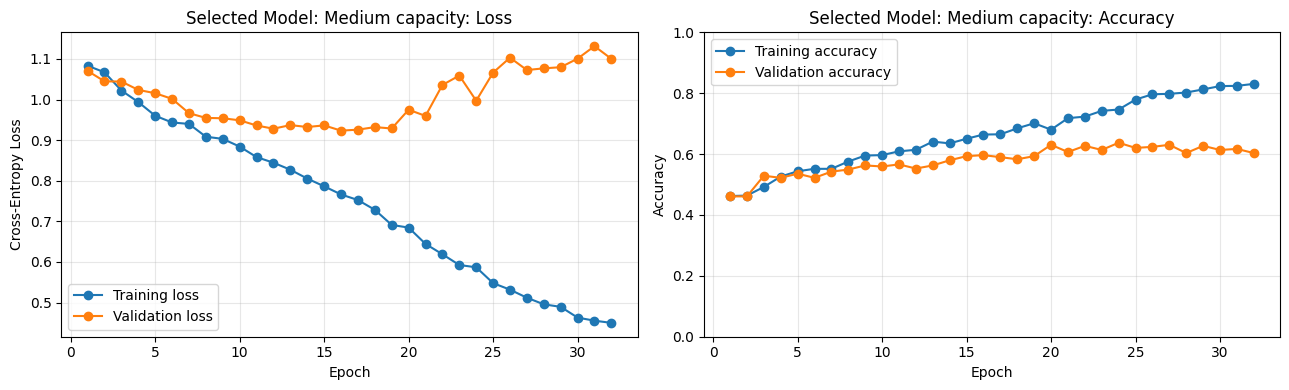

In [16]:
tf.keras.backend.clear_session()
best_model = build_model_from_config(best_config)
best_model.set_weights(best_weights)

print(f'Selected model: {best_trial_name}')
best_model.summary()

best_parameter_counts = count_model_parameters(best_model)
print('\nSelected model parameter counts:')
for parameter_name, parameter_value in best_parameter_counts.items():
    print(f'  {parameter_name}: {parameter_value:,}')

plot_training_history(
    best_history,
    f'Selected Model: {best_trial_name}',
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Selected CNN validation metrics:


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Selected CNN Validation: Medium capacity,0.6373,0.6168,0.5899,0.5899,0.5965,0.6296,0.6373,0.6264


Selected CNN validation classification report:


,precision,recall,f1-score,support
straight,0.6647,0.8162,0.7327,136.0000
right-turn,0.6486,0.5393,0.5890,89.0000
left-turn,0.5370,0.4143,0.4677,70.0000
accuracy,0.6373,0.6373,0.6373,0.6373
macro avg,0.6168,0.5899,0.5965,295.0000
weighted avg,0.6296,0.6373,0.6264,295.0000


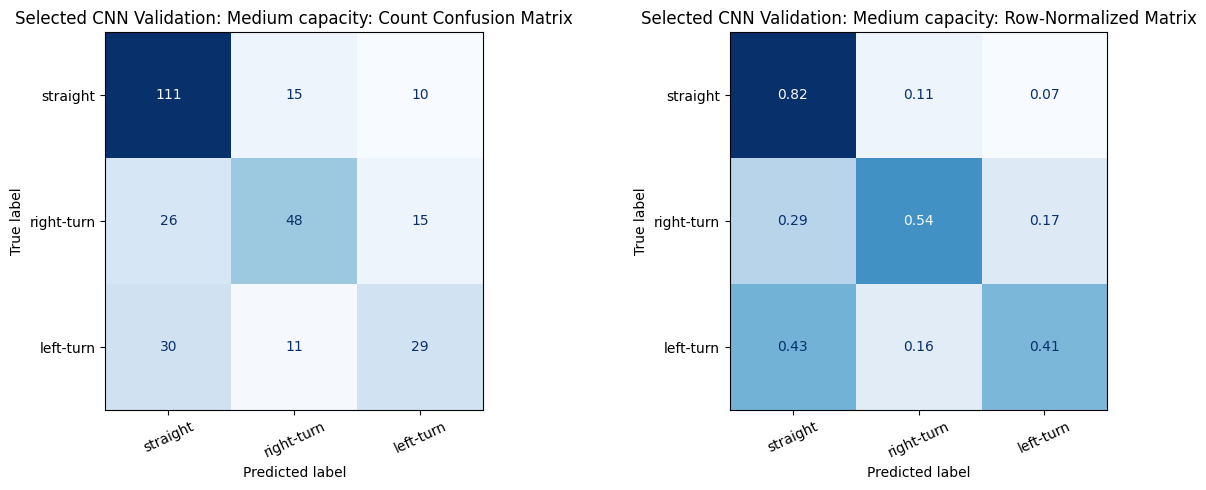

In [17]:
validation_probabilities = best_model.predict(
    X_val,
    batch_size=best_config['batch_size'],
    verbose=1,
)
validation_predictions = np.argmax(
    validation_probabilities,
    axis=1,
)

selected_validation_metrics = calculate_metrics(
    y_val,
    validation_predictions,
    f'Selected CNN Validation: {best_trial_name}',
)

print('Selected CNN validation metrics:')
display(
    pd.DataFrame([selected_validation_metrics])
    .set_index('model')
    .round(4)
)

print('Selected CNN validation classification report:')
display(
    classification_report_df(
        y_val,
        validation_predictions,
    ).round(4)
)

plot_confusion_matrices(
    y_val,
    validation_predictions,
    f'Selected CNN Validation: {best_trial_name}',
)

# Step 11: Evaluate the two baseline models on the test split

Chance baseline: predicts each of the three classes with equal probability. Its theoretical expected accuracy is 1/3, although the realized test accuracy can differ slightly.

Majority-class baseline: determines the most common class from y_train and predicts that class for every test image. It does not inspect the test labels when choosing the class.

Theoretical chance accuracy: 0.3333
Majority class from training data: straight (634 training images)

Chance Baseline


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Chance Baseline,0.322,0.3269,0.3232,0.3232,0.3167,0.3558,0.322,0.3293


,precision,recall,f1-score,support
straight,0.4725,0.3162,0.3789,136.000
right-turn,0.2710,0.3295,0.2974,88.000
left-turn,0.2371,0.3239,0.2738,71.000
accuracy,0.3220,0.3220,0.3220,0.322
macro avg,0.3269,0.3232,0.3167,295.000
weighted avg,0.3558,0.3220,0.3293,295.000


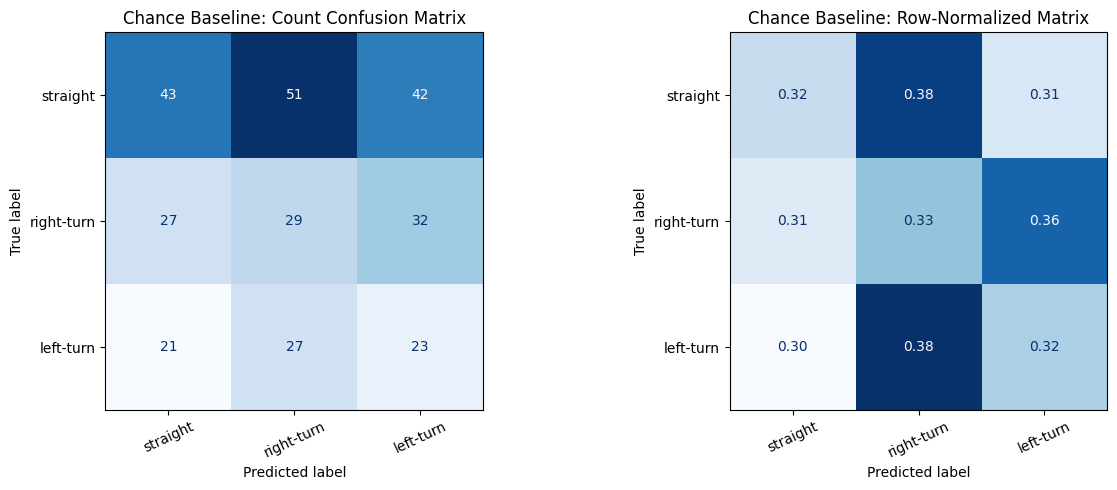


Majority-Class Baseline


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Majority-Class Baseline,0.461,0.1537,0.3333,0.3333,0.2104,0.2125,0.461,0.2909


,precision,recall,f1-score,support
straight,0.4610,1.0000,0.6311,136.000
right-turn,0.0000,0.0000,0.0000,88.000
left-turn,0.0000,0.0000,0.0000,71.000
accuracy,0.4610,0.4610,0.4610,0.461
macro avg,0.1537,0.3333,0.2104,295.000
weighted avg,0.2125,0.4610,0.2909,295.000


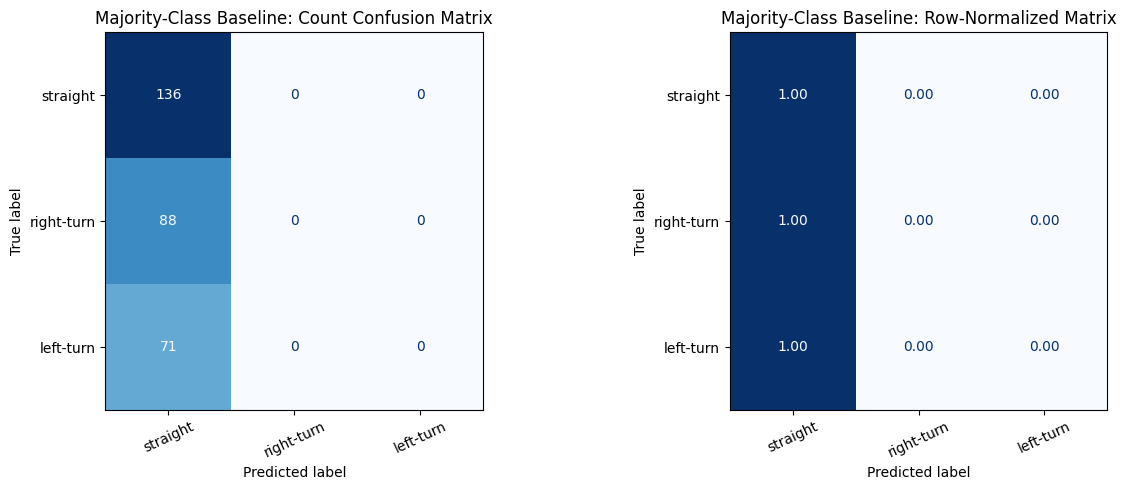

In [18]:
# Uniform random chance predictions with a fixed seed.
chance_rng = np.random.default_rng(SEED)
chance_predictions = chance_rng.integers(
    low=0,
    high=NUM_CLASSES,
    size=len(y_test),
)

# Determine the most common class using only the training labels.
training_class_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES,
)
majority_class_id = int(np.argmax(training_class_counts))
majority_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class_id,
    dtype=np.int32,
)

print(f'Theoretical chance accuracy: {1 / NUM_CLASSES:.4f}')
print(
    f'Majority class from training data: '
    f'{ID_TO_CLASS[majority_class_id]} '
    f'({training_class_counts[majority_class_id]:,} training images)'
)

baseline_predictions = {
    'Chance Baseline': chance_predictions,
    'Majority-Class Baseline': majority_predictions,
}
baseline_metric_rows = []

for baseline_name, predictions in baseline_predictions.items():
    print('\n' + '=' * 100)
    print(baseline_name)

    baseline_metrics = calculate_metrics(
        y_test,
        predictions,
        baseline_name,
    )
    baseline_metric_rows.append(baseline_metrics)

    display(
        pd.DataFrame([baseline_metrics])
        .set_index('model')
        .round(4)
    )
    display(
        classification_report_df(
            y_test,
            predictions,
        ).round(4)
    )
    plot_confusion_matrices(
        y_test,
        predictions,
        baseline_name,
    )

# Step 12: Report final CNN metrics on the untouched test split

This is the first use of the test images for the CNN. The selected model is evaluated once after all hyperparameter decisions are complete.

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5627 - loss: 1.0098
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
TensorFlow test evaluation:
  accuracy: 0.5627
  loss: 1.0098

CNN test metrics:


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Selected CNN: Medium capacity,0.5627,0.5207,0.5155,0.5155,0.5159,0.5495,0.5627,0.554


CNN test classification report:


,precision,recall,f1-score,support
straight,0.6601,0.7426,0.6990,136.0000
right-turn,0.4881,0.4659,0.4767,88.0000
left-turn,0.4138,0.3380,0.3721,71.0000
accuracy,0.5627,0.5627,0.5627,0.5627
macro avg,0.5207,0.5155,0.5159,295.0000
weighted avg,0.5495,0.5627,0.5540,295.0000


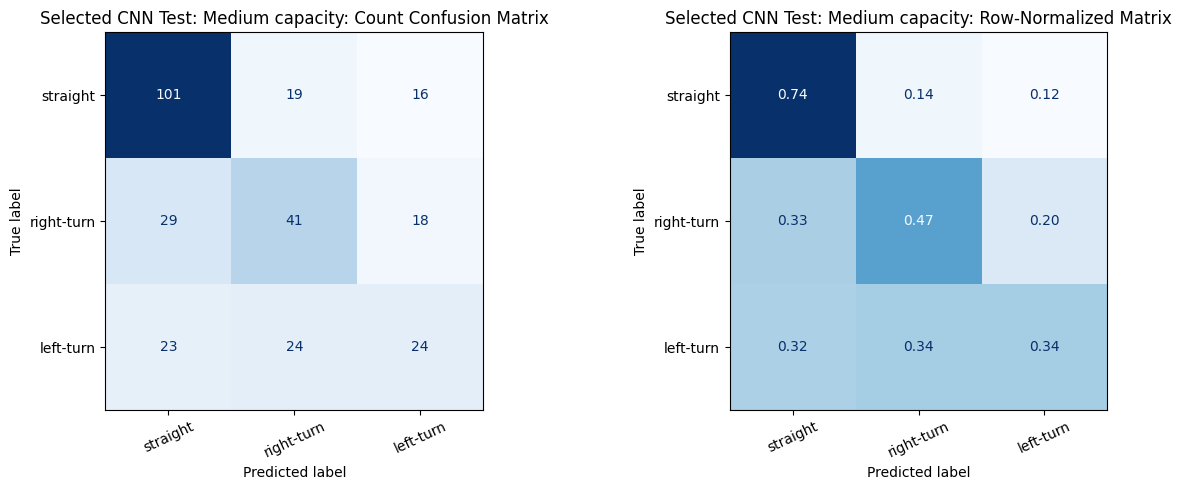

In [19]:
test_evaluation = best_model.evaluate(
    X_test,
    y_test,
    batch_size=best_config['batch_size'],
    verbose=1,
    return_dict=True,
)

test_probabilities = best_model.predict(
    X_test,
    batch_size=best_config['batch_size'],
    verbose=1,
)
test_predictions = np.argmax(
    test_probabilities,
    axis=1,
)

cnn_test_metrics = calculate_metrics(
    y_test,
    test_predictions,
    f'Selected CNN: {best_trial_name}',
)

print('TensorFlow test evaluation:')
for metric_name, metric_value in test_evaluation.items():
    print(f'  {metric_name}: {metric_value:.4f}')

print('\nCNN test metrics:')
display(
    pd.DataFrame([cnn_test_metrics])
    .set_index('model')
    .round(4)
)

print('CNN test classification report:')
display(
    classification_report_df(
        y_test,
        test_predictions,
    ).round(4)
)

plot_confusion_matrices(
    y_test,
    test_predictions,
    f'Selected CNN Test: {best_trial_name}',
)

# Step 13: Compare the CNN with both baselines

Final test-set model comparison:


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Chance Baseline,0.3220,0.3269,0.3232,0.3232,0.3167,0.3558,0.3220,0.3293
Majority-Class Baseline,0.4610,0.1537,0.3333,0.3333,0.2104,0.2125,0.4610,0.2909
Selected CNN: Medium capacity,0.5627,0.5207,0.5155,0.5155,0.5159,0.5495,0.5627,0.5540


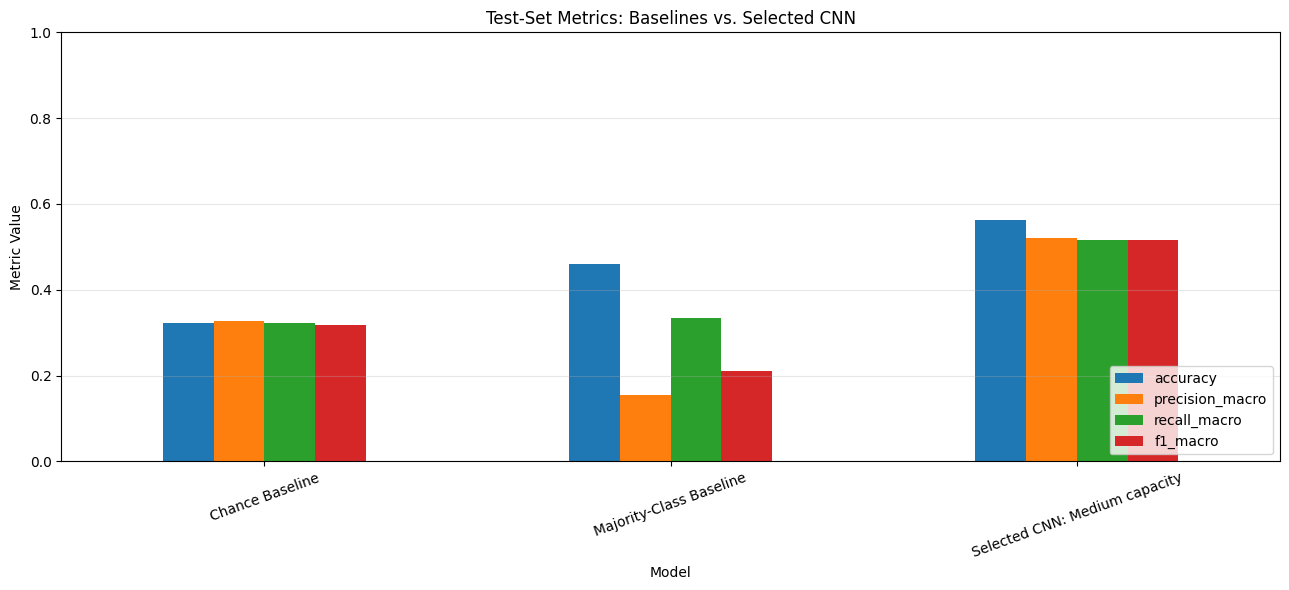

In [20]:
comparison_df = pd.DataFrame(
    baseline_metric_rows + [cnn_test_metrics]
).set_index('model')

print('Final test-set model comparison:')
display(comparison_df.round(4))

comparison_columns = [
    'accuracy',
    'precision_macro',
    'recall_macro',
    'f1_macro',
]

ax = comparison_df[comparison_columns].plot(
    kind='bar',
    figsize=(13, 6),
    ylim=(0, 1),
)

ax.set_title('Test-Set Metrics: Baselines vs. Selected CNN')
ax.set_xlabel('Model')
ax.set_ylabel('Metric Value')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Output Penultimate feature vector to be used in downstream Classification


In [22]:
# Save learned CNN features and corresponding labels.
FEATURES_DIR = (
    PROJECT_ROOT
    / 'data'
    / 'processed'
    / 'waymo_e2e'
    / 'features'
)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

CNN_FEATURE_PATH = FEATURES_DIR / 'CNN_2D.npy'
CNN_LABEL_PATH = FEATURES_DIR / 'labels_CNN_2D.npy'

# Use the final hidden layer as the learned CNN feature vector.
cnn_feature_extractor = tf.keras.Model(
    inputs=best_model.inputs,
    outputs=best_model.get_layer('dense_hidden').output,
    name='cnn_2d_feature_extractor',
)

X_by_split = {
    'train': X_train,
    'val': X_val,
    'test': X_test,
}

cnn_feature_splits = []

for split_name in SPLIT_NAMES:
    print(f'Extracting {split_name} CNN features...')

    split_features = cnn_feature_extractor.predict(
        X_by_split[split_name],
        batch_size=best_config['batch_size'],
        verbose=1,
    )

    cnn_feature_splits.append(
        split_features.astype(np.float32)
    )

    print(
        f'  {split_name}: '
        f'{split_features.shape}'
    )

# Preserve train, validation, and test ordering.
cnn_features = np.concatenate(
    cnn_feature_splits,
    axis=0,
)

# Save readable class names rather than encoded integers.
cnn_labels = np.concatenate([
    split_label_dfs[split_name]['class_label']
    .astype(str)
    .to_numpy()
    for split_name in SPLIT_NAMES
]).astype('<U20')

if cnn_features.shape[0] != cnn_labels.shape[0]:
    raise ValueError(
        f'Feature/label row mismatch: '
        f'{cnn_features.shape[0]} features and '
        f'{cnn_labels.shape[0]} labels.'
    )

if not np.isfinite(cnn_features).all():
    raise ValueError(
        'CNN features contain NaN or infinite values.'
    )

np.save(CNN_FEATURE_PATH, cnn_features)
np.save(CNN_LABEL_PATH, cnn_labels)

print('\nSaved CNN feature files:')
print(f'  {CNN_FEATURE_PATH}')
print(f'  {CNN_LABEL_PATH}')
print(f'\nCNN feature shape: {cnn_features.shape}')
print(f'CNN label shape: {cnn_labels.shape}')

# Print the row boundaries for each split.
row_start = 0

for split_name in SPLIT_NAMES:
    row_end = row_start + len(X_by_split[split_name])

    print(
        f'{split_name}: rows '
        f'{row_start:,} through {row_end - 1:,}'
    )

    row_start = row_end

print('\nLabel distribution:')
print(
    pd.Series(cnn_labels)
    .value_counts()
    .reindex(CLASS_NAMES)
)

Extracting train CNN features...
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
  train: (1376, 64)
Extracting val CNN features...
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
  val: (295, 64)
Extracting test CNN features...
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
  test: (295, 64)

Saved CNN feature files:
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\features\CNN_2D.npy
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\features\labels_CNN_2D.npy

CNN feature shape: (1966, 64)
CNN label shape: (1966,)
train: rows 0 through 1,375
val: rows 1,376 through 1,670
test: rows 1,671 through 1,965

Label distribution:
straight      906
right-turn    589
left-turn     471
Name: count, dtype: int64
